Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       10000 non-null  int64  
 1   term            10000 non-null  int64  
 2   int_rate        10000 non-null  float64
 3   annual_inc      10000 non-null  int64  
 4   emp_length      10000 non-null  int64  
 5   home_ownership  10000 non-null  object 
 6   purpose         10000 non-null  object 
 7   grade           10000 non-null  object 
 8   loan_status     10000 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 703.3+ KB
None

Missing Values
loan_amnt         0
term              0
int_rate          0
annual_inc        0
emp_length        0
home_ownership    0
purpose           0
grade             0
loan_status       0
dtype: int64

Statistics
          loan_amnt        term      int_rate     annual_inc    emp_length
count  10000.

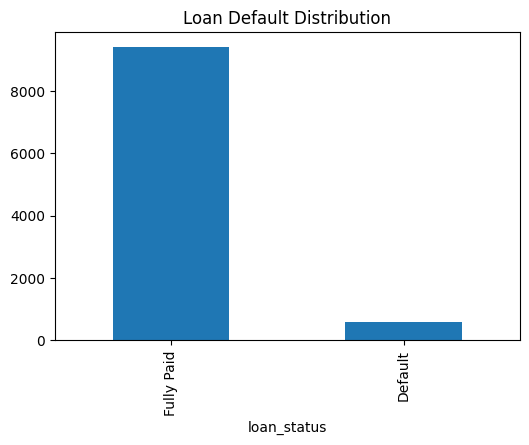

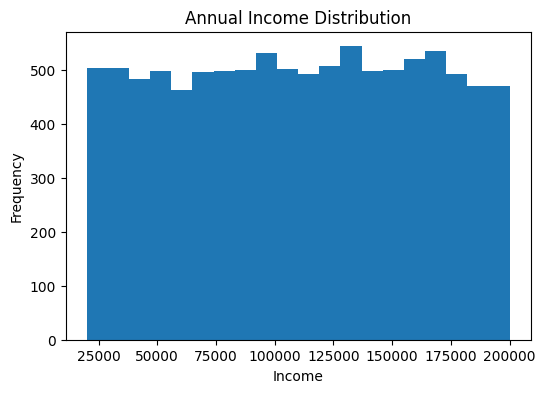

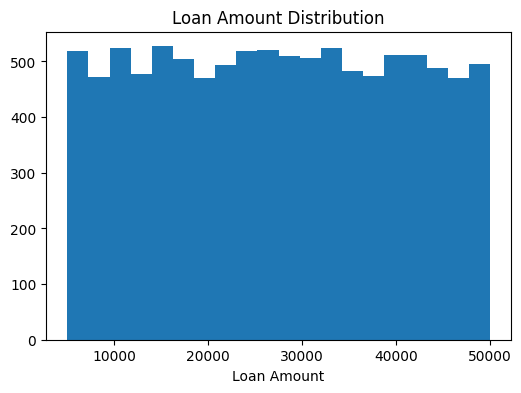

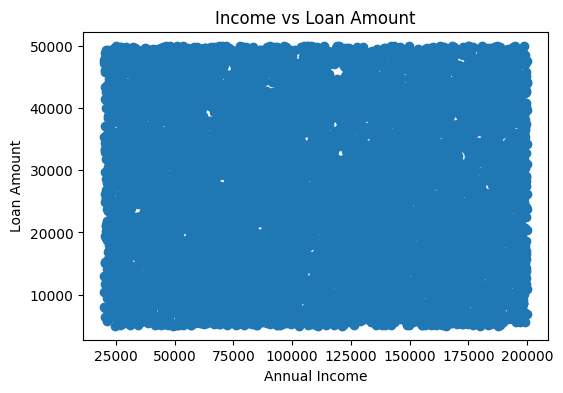

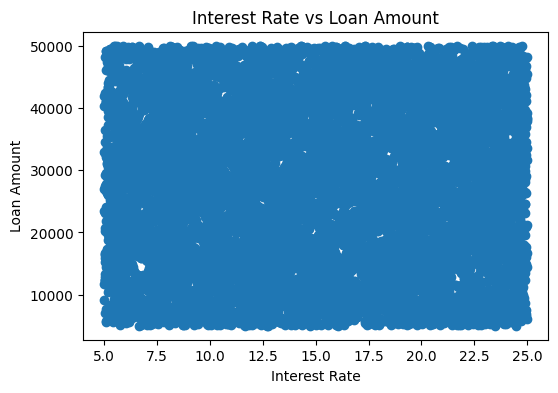

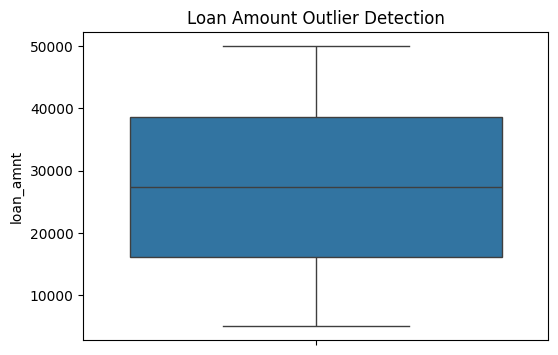

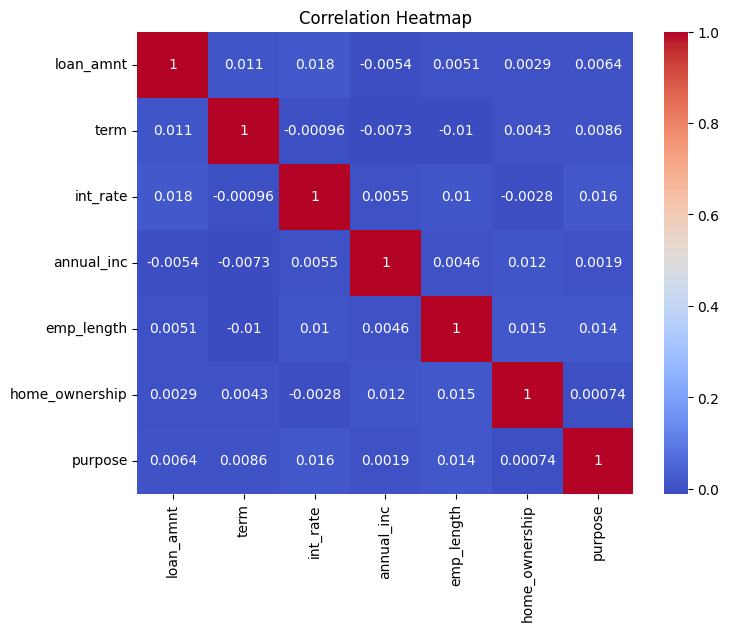


Dataset saved as loan_default_prediction.csv

--- Insights ---
Low income borrowers show higher default risk.
Higher interest rates increase default probability.
Income strongly influences loan approval decisions.
Risk categories help identify potential defaulters.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ----------------------------
# Generate Loan Dataset
# ----------------------------

np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "loan_amnt": np.random.randint(5000, 50000, n),
    "term": np.random.choice([36, 60], n),
    "int_rate": np.random.uniform(5, 25, n),
    "annual_inc": np.random.randint(20000, 200000, n),
    "emp_length": np.random.randint(0, 20, n),
    "home_ownership": np.random.choice(
        ["RENT", "OWN", "MORTGAGE"],
        n
    ),
    "purpose": np.random.choice(
        ["car", "education", "home", "business"],
        n
    ),
    "grade": np.random.choice(
        ["A", "B", "C", "D", "E"],
        n
    )
})

# ----------------------------
# Loan Status
# ----------------------------

data["loan_status"] = np.where(
    (data["annual_inc"] < 40000) &
    (data["int_rate"] > 15),
    "Default",
    "Fully Paid"
)

# ----------------------------
# Dataset Information
# ----------------------------

print("Dataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())

print("\nStatistics")
print(data.describe())

# ----------------------------
# Default Analysis
# ----------------------------

print("\nLoan Status Distribution")
print(data["loan_status"].value_counts())

# ----------------------------
# Risk Classification
# ----------------------------

def risk_category(row):
    if row["annual_inc"] < 40000:
        return "High Risk"
    elif row["annual_inc"] < 80000:
        return "Medium Risk"
    else:
        return "Low Risk"

data["Risk"] = data.apply(
    risk_category,
    axis=1
)

print("\nRisk Distribution")
print(data["Risk"].value_counts())

# ----------------------------
# Group Analysis
# ----------------------------

income_default = data.groupby(
    "loan_status"
)["annual_inc"].mean()

print("\nIncome vs Default")
print(income_default)

purpose_default = pd.crosstab(
    data["purpose"],
    data["loan_status"]
)

print("\nPurpose vs Default")
print(purpose_default)

# ----------------------------
# Encode Categories
# ----------------------------

data["home_ownership"] = data[
    "home_ownership"
].astype("category").cat.codes

data["purpose"] = data[
    "purpose"
].astype("category").cat.codes

# ----------------------------
# Linear Regression
# ----------------------------

X = data[
    ["annual_inc",
     "int_rate",
     "term"]
]

y = data["loan_amnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

score = r2_score(
    y_test,
    predictions
)

print("\nR2 Score:", score)

# ----------------------------
# Visualizations
# ----------------------------

# Default Distribution

plt.figure(figsize=(6,4))
data["loan_status"].value_counts().plot(
    kind="bar"
)
plt.title("Loan Default Distribution")
plt.show()

# Income Distribution

plt.figure(figsize=(6,4))
plt.hist(
    data["annual_inc"],
    bins=20
)
plt.title("Annual Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Loan Amount Distribution

plt.figure(figsize=(6,4))
plt.hist(
    data["loan_amnt"],
    bins=20
)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.show()

# Income vs Loan Amount

plt.figure(figsize=(6,4))
plt.scatter(
    data["annual_inc"],
    data["loan_amnt"]
)
plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

# Interest Rate vs Loan Amount

plt.figure(figsize=(6,4))
plt.scatter(
    data["int_rate"],
    data["loan_amnt"]
)
plt.title("Interest Rate vs Loan Amount")
plt.xlabel("Interest Rate")
plt.ylabel("Loan Amount")
plt.show()

# Box Plot

plt.figure(figsize=(6,4))
sns.boxplot(
    y=data["loan_amnt"]
)
plt.title("Loan Amount Outlier Detection")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_data = data.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ----------------------------
# Save Dataset
# ----------------------------

data.to_csv(
    "loan_default_prediction.csv",
    index=False
)

print("\nDataset saved as loan_default_prediction.csv")

# ----------------------------
# Insights
# ----------------------------

print("\n--- Insights ---")
print("Low income borrowers show higher default risk.")
print("Higher interest rates increase default probability.")
print("Income strongly influences loan approval decisions.")
print("Risk categories help identify potential defaulters.")